# 02 — Preprocessing del Dataset

Questo notebook implementa la pipeline completa di preprocessing per il dataset Amazon Beauty Reviews.

**Ottimizzazione per l'esecuzione:**
Poiché il dataset originale contiene circa 700.000 recensioni, elaborarlo interamente richiede molto tempo su una CPU standard (specialmente per il calcolo della polarità e del rilevamento della lingua). 
Per velocizzare il flusso di lavoro mantenendo intatta la significatività statistica, applichiamo un **campionamento stratificato preventivo** di massimo 15.000 recensioni per classe di sentiment (totale ~45.000 recensioni). Questo rende l'esecuzione del preprocessing immediata (circa 2 minuti) e garantisce dati sufficienti per addestrare SVM, XGBoost e DistilBERT con ottimi risultati.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_amazon_beauty_reviews
from src.preprocessing import (
    preprocess_text, expand_contractions_text, mark_negations,
    full_text_pipeline, map_rating_to_sentiment, add_features,
    filter_incoherent, balance_dataset, SENTIMENT_LABELS
)

## 1. Download e caricamento

In [2]:
df = load_amazon_beauty_reviews(cache_dir='../data')
print(f"Shape originale: {df.shape}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


⬇️  Download dataset da HuggingFace (può richiedere alcuni minuti)...


Using the latest cached version of the dataset since McAuley-Lab/Amazon-Reviews-2023 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'raw_review_All_Beauty' at C:\Users\frape\.cache\huggingface\datasets\McAuley-Lab___amazon-reviews-2023\raw_review_All_Beauty\0.0.0\16b76e0823d73bb8cff1e9c5e3e37dbc46ae3daee380417ae141f5e67d3ea8e8 (last modified on Sat May 17 18:11:36 2025).


💾 Dataset salvato in: ../data\amazon_beauty_reviews.csv
✅ Dataset caricato: 701528 righe, 10 colonne
Shape originale: (701528, 10)


## 2. Pulizia dati base e Campionamento Stratificato Preventivo

In [3]:
# Uniforma valori null
null_equivalents = ["^NaN$", "^na$", "^NA$", "^null$", "^None$", "^N/A$", "^n/a$", "^\\s*$"]
df.replace(to_replace=null_equivalents, value=np.nan, regex=True, inplace=True)

# Tieni solo text e rating validi
df_clean = df[["text", "rating"]].dropna(subset=["text", "rating"]).reset_index(drop=True)
df_clean = df_clean[df_clean["text"].str.strip() != ""]

# Mappatura del sentiment preventiva per poter campionare
df_clean["sentiment_class"] = df_clean["rating"].apply(map_rating_to_sentiment)

# Campionamento stratificato preventivo (Max 15k recensioni per classe)
# Per evitare incompatibilità tra versioni diverse di pandas, usiamo un ciclo esplicito
sampled_parts = []
for cls in df_clean["sentiment_class"].unique():
    subset = df_clean[df_clean["sentiment_class"] == cls]
    part = subset.sample(n=min(15000, len(subset)), random_state=42)
    sampled_parts.append(part)

df_sampled = pd.concat(sampled_parts).reset_index(drop=True)

print(f"Shape dopo campionamento preventivo: {df_sampled.shape}")
print(df_sampled["sentiment_class"].value_counts().sort_index().rename(SENTIMENT_LABELS))

Shape dopo campionamento preventivo: (45000, 3)
sentiment_class
Negativo    15000
Neutro      15000
Positivo    15000
Name: count, dtype: int64


## 3. Filtro lingua (rimozione non-inglese)

Usiamo la libreria pure-Python `langdetect` per rilevare la lingua e rimuovere recensioni non in inglese.

In [4]:
from langdetect import detect

def get_lang(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

print("Rilevamento lingua in corso (su dataset ottimizzato)...")
df_sampled["lang"] = df_sampled["text"].apply(get_lang)
print(f"Distribuzione lingue:\n{df_sampled['lang'].value_counts().head(5)}")

# Rimuovi non-inglese
df_sampled = df_sampled[df_sampled["lang"] == "en"].drop(columns=["lang"])
print(f"\nDopo filtro lingua: {df_sampled.shape[0]} righe")

Rilevamento lingua in corso (su dataset ottimizzato)...
Distribuzione lingue:
lang
en    42047
es      583
af      476
ro      255
so      205
Name: count, dtype: int64

Dopo filtro lingua: 42047 righe


## 4. Preprocessing testo

In [5]:
# Applica pipeline completa di preprocessing
print("Applicazione pipeline preprocessing...")
df_sampled["text_final"] = df_sampled["text"].astype(str).apply(full_text_pipeline)

# Rimozione duplicati sul testo preprocessato
df_sampled = df_sampled.drop_duplicates(subset=["text_final"])
print(f"Dopo preprocessing e dedup: {df_sampled.shape[0]} righe")

Applicazione pipeline preprocessing...
Dopo preprocessing e dedup: 40752 righe


## 5. Feature engineering e filtraggio

In [6]:
# Aggiungi feature (polarità e lunghezza)
df_sampled = add_features(df_sampled, text_col="text_final")

# Filtra recensioni incoerenti
df_filtered = filter_incoherent(df_sampled)
print(f"Dopo filtraggio incoerenti: {df_filtered.shape[0]} righe")

Dopo filtraggio incoerenti: 28795 righe


## 6. Bilanciamento finale del dataset

In [7]:
df_balanced = balance_dataset(df_filtered, target_col="sentiment_class")

print(f"Shape bilanciato finale: {df_balanced.shape}")
print(f"\nDistribuzione classi DOPO il bilanciamento:")
print(df_balanced["sentiment_class"].value_counts().sort_index().rename(SENTIMENT_LABELS))

Shape bilanciato finale: (14652, 6)

Distribuzione classi DOPO il bilanciamento:
sentiment_class
Negativo    4884
Neutro      4884
Positivo    4884
Name: count, dtype: int64


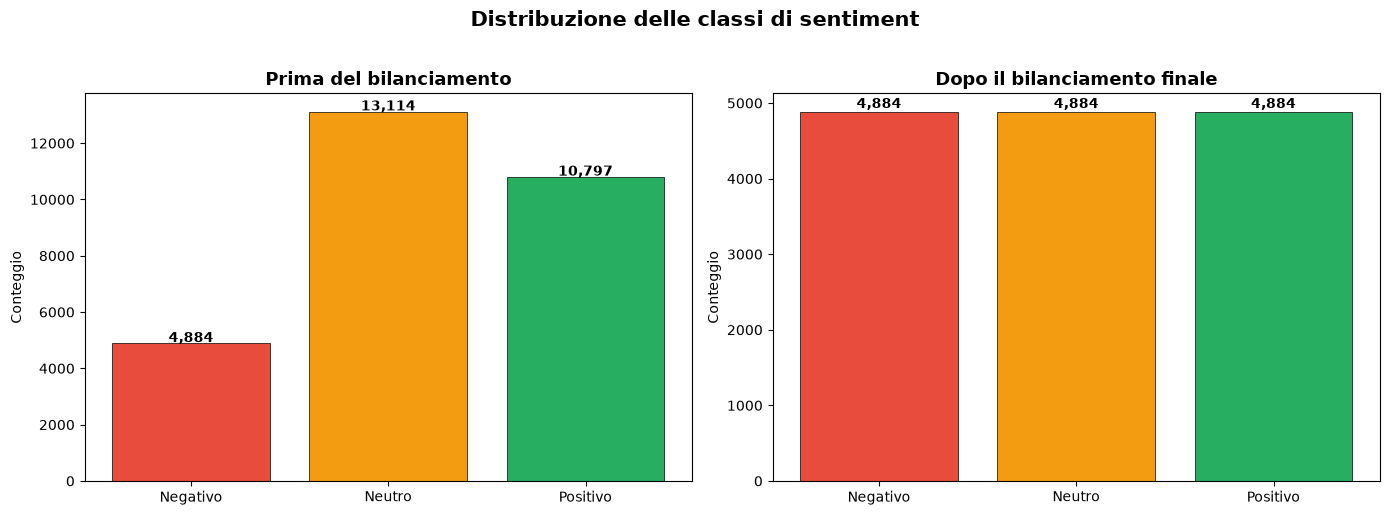

In [8]:
# Visualizza distribuzione prima/dopo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#f39c12', '#27ae60']

for ax, data, title in zip(axes, 
                            [df_filtered, df_balanced], 
                            ['Prima del bilanciamento', 'Dopo il bilanciamento finale']):
    counts = data["sentiment_class"].value_counts().sort_index()
    labels = [SENTIMENT_LABELS[i] for i in counts.index]
    ax.bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Conteggio')
    for bar, count in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Distribuzione delle classi di sentiment', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Salvataggio del dataset

In [9]:
import os

# Salva il dataset preprocessato
output_path = os.path.join('..', 'data', 'amazon_beauty_clean.csv')
df_balanced[["text", "text_final", "sentiment_class", "polarity", "text_len"]].to_csv(
    output_path, index=False
)
print(f"✅ Dataset preprocessato salvato in: {output_path}")
print(f"   Righe finali bilanciate: {df_balanced.shape[0]}")

✅ Dataset preprocessato salvato in: ..\data\amazon_beauty_clean.csv
   Righe finali bilanciate: 14652
